# Output-Informed Tokenization for Disordered Lattices

This notebook sets up a first output-informed tokenization workflow using your existing UT/CT simulation dataset.

## Objectives
- Use existing disordered samples (better/similar/worse than periodic).
- Build discrete node-level tokens from displacement fields (`dx, dy`).
- Make token discovery output-informed via UT/CT performance metrics.
- Save token artifacts for later interpretation and FEA intervention tests.

## Pipeline
1. Load aligned UT/CT dataset.
2. Build a combined score from selected mechanical objectives.
3. Build neighborhood graph from periodic node coordinates.
4. Learn supervised patch embeddings and discrete codebook tokens.
5. Run diagnostics (entropy, elite enrichment, MI proxy).
6. Save token IDs and summaries.

In [1]:
from resources.MLdata import DATA
from resources.tokenization import TokenizationConfig, OutputInformedTokenizer, prepare_xy_from_data_object, save_tokenization_artifacts

import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Configure dataset loading (edit to your current setup)
data = DATA(
    path=1, 
    path_add="",
    load=True, 
    LAT="FCC", 
    dis="disNodes", 
    dN=0.2, 
    mechMode="both",
    multi=True,
    model="MLP",
)

# Output-informed objective definition
objectives = ["Ductility", "WoF", "K_JIC", "Displacement"]
weights = [1.0, 1.0, 1.0, 1.0]

X_nodes, base_nodes, score, props_df = prepare_xy_from_data_object(
    data,
    objectives=objectives,
    weights=weights,
    use_ft_inputs=False,
)

print("X_nodes shape:", X_nodes.shape)
print("base_nodes shape:", base_nodes.shape)
print("score shape:", score.shape)

c:\Users\exy053\OneDrive - Queen Mary, University of London\Documents\Research\p1-LatticeFractureToughness\p1git-Lattices\code\resources\lattices.py:637: RuntimeWarning: divide by zero encountered in double_scalars
  return np.array([np.cos(np.arctan([n0[1]/n0[0]]))[0], np.sin(np.arctan([n0[1]/n0[0]]))[0]])


X_nodes shape: (6818, 722, 2)
base_nodes shape: (722, 2)
score shape: (6818,)


In [6]:
# Tokenizer config
cfg = TokenizationConfig(
    n_tokens=32,
    k_neighbors=6,
    elite_quantile=0.90,
    embedding_dim=8,
    random_state=42,
)

tokenizer = OutputInformedTokenizer(cfg)
tokenizer.fit(X_nodes, base_nodes, score)
token_ids = tokenizer.tokenize(X_nodes)
diag = tokenizer.diagnostics(token_ids, score)

print(f"Normalized token entropy: {diag['entropy_norm']:.4f}")
print(f"Elite threshold (score): {diag['elite_threshold']:.4f}")

Normalized token entropy: 0.9991
Elite threshold (score): 1.1837


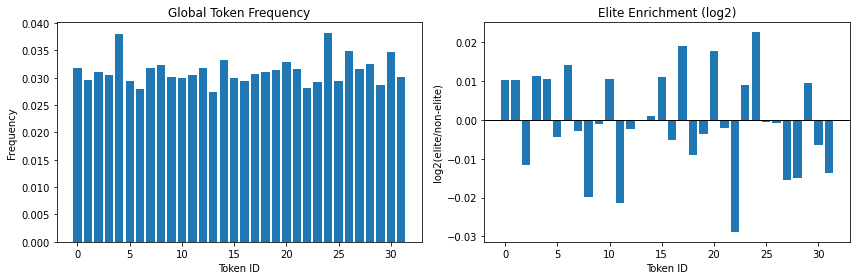

In [7]:
# Basic diagnostics plots
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].bar(np.arange(len(diag['global_token_freq'])), diag['global_token_freq'])
axs[0].set_title("Global Token Frequency")
axs[0].set_xlabel("Token ID")
axs[0].set_ylabel("Frequency")

axs[1].bar(np.arange(len(diag['token_enrichment_log2'])), diag['token_enrichment_log2'])
axs[1].axhline(0.0, color="black", linewidth=1)
axs[1].set_title("Elite Enrichment (log2)")
axs[1].set_xlabel("Token ID")
axs[1].set_ylabel("log2(elite/non-elite)")

plt.tight_layout()
plt.show()

In [8]:
# Save artifacts
out_dir = f"{data.PATH}MLdata/tokenization/"
save_tokenization_artifacts(out_dir, token_ids, diag, cfg)
print("Saved tokenization artifacts to:", out_dir)

Saved tokenization artifacts to: Z:/p1/data/Ti/disNodes//0.2/FCC/MLdata/tokenization/


## Recommended Next Runs
Run this notebook with:
- `n_tokens in [16, 32, 64]`
- `k_neighbors in [4, 6, 8]`
- objective sets: `UT-only`, `CT-only`, `combined`

Then compare stability of top enriched tokens across runs before FEA intervention testing.